- The text dataset is located at https://huggingface.co/datasets/Luka582/Novi-Sad-Monuments
- The train dataset is just the google landmarks v2 dataset, with the csv that includes all the relevant labels. (Monaasteries, sculptures, museums, fortresses...)

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
import timm
import pandas as pd
import matplotlib.pyplot as plt
from utils import *
torch.set_float32_matmul_precision("high")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
IMG_SIZE = 384
EMB_DIM = 512
TRAIN_BATCH_SIZE = 256
INFERENCE_BATCH_SIZE = 256
EPOCHS = 30
UNFREEZING_EPOCH = 4
LR = 2e-3
WEIGHT_DECAY = 1e-4

In [4]:
train_dataset = TrainDataset("landmarks_data/train_dataset", transform=make_train_transform(IMG_SIZE))

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=10,
)

(query_data, index_data), _ = make_query_index_split("landmarks_data/test_dataset", num_of_queries_per_class=1, seed=42)
query_dataset = TestDataset(query_data, transform=make_inference_transform(IMG_SIZE))
index_dataset = TestDataset(index_data, transform=make_inference_transform(IMG_SIZE))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Backbone frozen.
Currently on epoch 1/30
batch        901/901
Running Validation...
Stats on epoch 1/30: loss =     24.818, map =    0.77705, r1 =    0.84762, r3 =    0.91429
Currently on epoch 2/30
batch        901/901
Running Validation...
Stats on epoch 2/30: loss =     16.322, map =    0.77531, r1 =    0.82857, r3 =    0.91429
Currently on epoch 3/30
batch        901/901
Running Validation...
Stats on epoch 3/30: loss =     13.714, map =    0.80365, r1 =     0.8381, r3 =    0.92381
Currently on epoch 4/30
Backbone unfrozen.
batch        901/901
Running Validation...
Stats on epoch 4/30: loss =     10.564, map =     0.8704, r1 =    0.91429, r3 =    0.94286
Currently on epoch 5/30
batch        901/901
Running Validation...
Stats on epoch 5/30: loss =     7.1364, map =    0.87421, r1 =    0.92381, r3 =    0.94286
Currently on epoch 6/30
batch        901/901
Running Validation...
Stats on epoch 6/30: loss =     5.5522, map =    0.87489, r1 =    0.92381, r3 =    0.94286
Currently on epo

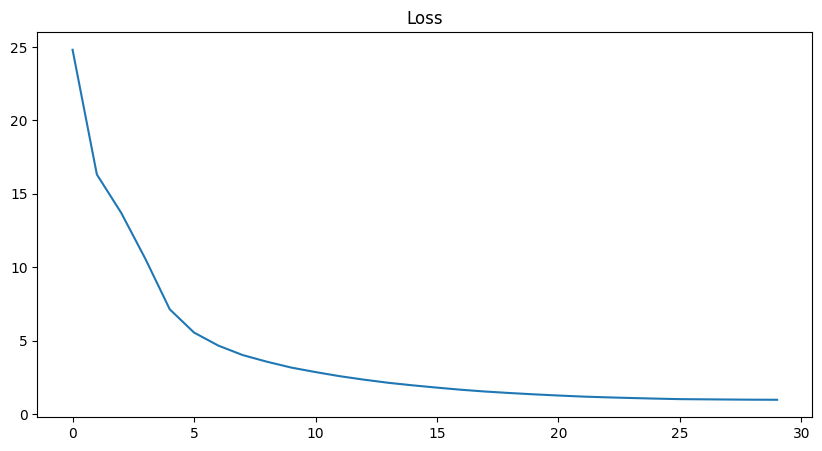

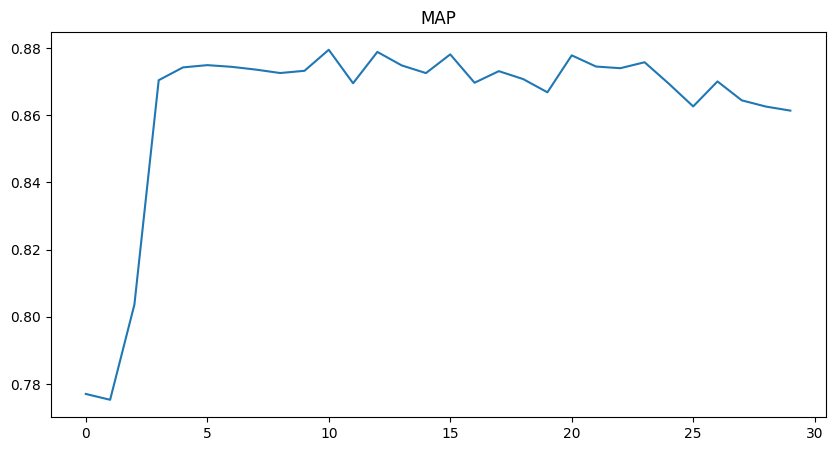

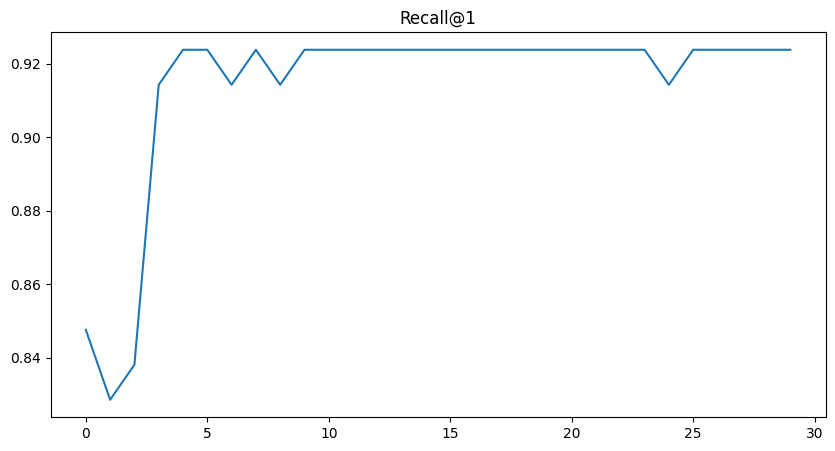

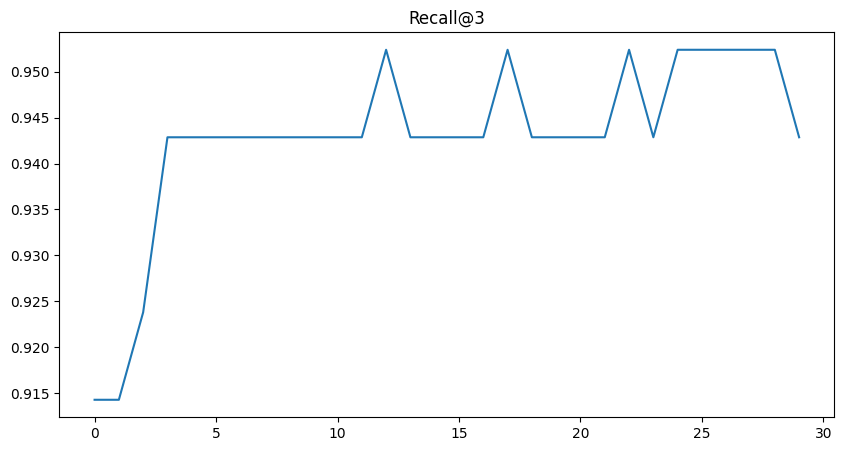

In [5]:
class_counts = train_dataset.df['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)

model = LandmarkModel(model_name='tf_efficientnetv2_s', num_classes=len(train_dataset.df["label"].unique()), emb_dim=EMB_DIM).to(device)
#model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - 3, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(weight=class_weights)
model.freeze_backbone()
print("Backbone frozen.")

loss_history = []
map_history = []
r1_history = []
r3_history = []
best_map = 0

for epoch in range(1, EPOCHS+1):
    print(f"Currently on epoch {epoch}/{EPOCHS}")
    if epoch == UNFREEZING_EPOCH:
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": LR * 0.02},
            {"params": model.pooling.parameters(), "lr": LR},
            {"params": model.neck.parameters(), "lr": LR},
            {"params": model.head.parameters(), "lr": LR},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - UNFREEZING_EPOCH, eta_min=1e-6
        )
        print("Backbone unfrozen.")

    model.train()
    total_loss = 0.0

    for i, (imgs, labels) in enumerate(train_loader):
        print(end="\r")
        print(f"batch {i+1:10}/{len(train_loader)}", end="")
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            logits = model(imgs, labels=labels)
            loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print()
    if epoch >= 3:
        scheduler.step()

    model.eval()
    avg_loss = total_loss/len(train_loader)

    with torch.no_grad():
        print("Running Validation...")
        map_score, r1, r3 = validate_test_set(
            model, query_dataset, index_dataset,
            batch_size=INFERENCE_BATCH_SIZE, device=device
        )

    if map_score > best_map:
        best_map = map_score
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "map": map_score,
        }, "best_model.pt")

    loss_history.append(avg_loss)
    map_history.append(map_score)
    r1_history.append(r1)
    r3_history.append(r3)
    print(f"Stats on epoch {epoch}/{EPOCHS}: loss = {avg_loss:10.5}, map = {map_score:10.5}, r1 = {r1:10.5}, r3 = {r3:10.5}")

plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.title("Loss")

plt.figure(figsize=(10,5))
plt.plot(map_history)
plt.title("MAP")

plt.figure(figsize=(10,5))
plt.plot(r1_history)
plt.title("Recall@1")

plt.figure(figsize=(10,5))
plt.plot(r3_history)
plt.title("Recall@3")

plt.show()

 - The model was saved on the 11th epoch, as the MAP was best then.

In [7]:
map, r1, r3 = validate_test_set(timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=0).to(device), query_dataset, index_dataset, INFERENCE_BATCH_SIZE, device)
print(f"Stats on the raw untrained EfficientNet: map = {map:10.5}, r1 = {r1:10.5}, r3 = {r3:10.5}")

Stats on the raw untrained EfficientNet: map =    0.64201, r1 =    0.45714, r3 =    0.51429


- The model performace had a significant increase in accuracy from the base model trained on ImageNet.